In [1]:
import fastf1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import splprep, splev
from scipy.signal import savgol_filter

fastf1.Cache.enable_cache('../cache')

session = fastf1.get_session(2024, 'Barcelona', 'Q')
session.load()
print("✅ Sesión cargada")

core           INFO 	Loading data for Spanish Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '1', '44', '63', '16', '55', '10', '11', '31', '81', '14', '77', '27', '18', '24', '20', '22', '3', '23', '2']


✅ Sesión cargada


In [2]:
# Cogemos las 5 vueltas más rápidas de pilotos distintos
laps = session.laps.pick_quicklaps()

# Mejor vuelta por piloto (sin groupby para preservar referencia a sesión)
drivers = laps["Driver"].unique()
best_per_driver = []
for driver in drivers:
    driver_laps = laps.pick_drivers(driver)
    if len(driver_laps) > 0:
        best = driver_laps.pick_fastest()
        best_per_driver.append(best)

# Ordenamos por tiempo y cogemos top 5
best_per_driver.sort(key=lambda x: x["LapTime"])
top5_laps = best_per_driver[:5]

print("=== TOP 5 VUELTAS ===")
for lap in top5_laps:
    print(f"  {lap['Driver']}  {lap['LapTime']}")

# Extraemos telemetría directamente desde el objeto Lap original
telemetries = []
for lap in top5_laps:
    try:
        tel = lap.get_telemetry()[["X", "Y", "Speed", "Distance"]].copy()
        tel["Driver"] = lap["Driver"]
        telemetries.append(tel)
        print(f"  ✅ {lap['Driver']}: {len(tel)} puntos")
    except Exception as e:
        print(f"  ⚠️ {lap['Driver']}: error — {e}")

print(f"\n✅ {len(telemetries)} vueltas con telemetría cargadas")

=== TOP 5 VUELTAS ===
  NOR  0 days 00:01:11.383000
  VER  0 days 00:01:11.403000
  HAM  0 days 00:01:11.701000
  RUS  0 days 00:01:11.703000
  LEC  0 days 00:01:11.731000
  ✅ NOR: 548 puntos
  ✅ VER: 550 puntos
  ✅ HAM: 555 puntos
  ✅ RUS: 559 puntos
  ✅ LEC: 544 puntos

✅ 5 vueltas con telemetría cargadas


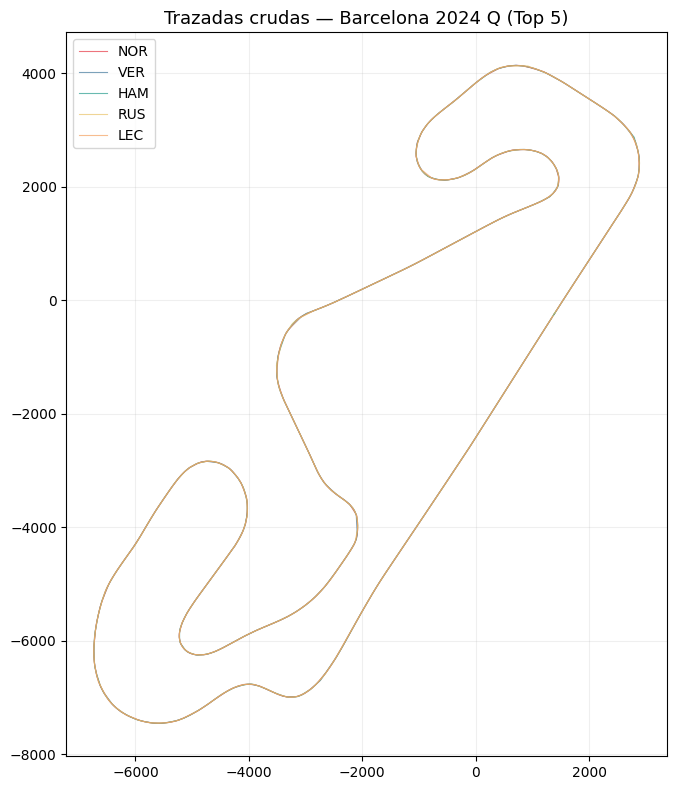

Puntos en la vuelta pole: 548
Rango X: [-6734, 2882] m
Rango Y: [-7456, 4143] m


In [3]:
fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#e63946", "#457b9d", "#2a9d8f", "#e9c46a", "#f4a261"]

for i, tel in enumerate(telemetries):
    ax.plot(tel["X"], tel["Y"], linewidth=0.8, alpha=0.7,
            color=colors[i], label=tel["Driver"].iloc[0])

ax.set_title("Trazadas crudas — Barcelona 2024 Q (Top 5)", fontsize=13)
ax.set_aspect("equal")
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Comprobamos ruido en X e Y
tel_pole = telemetries[0]
print(f"Puntos en la vuelta pole: {len(tel_pole)}")
print(f"Rango X: [{tel_pole['X'].min():.0f}, {tel_pole['X'].max():.0f}] m")
print(f"Rango Y: [{tel_pole['Y'].min():.0f}, {tel_pole['Y'].max():.0f}] m")

Procesando trazada pole...
  Longitud poligonal cruda: 4615.1 m
  Distancia inicio-fin (debe ser ~0): 2.308 m


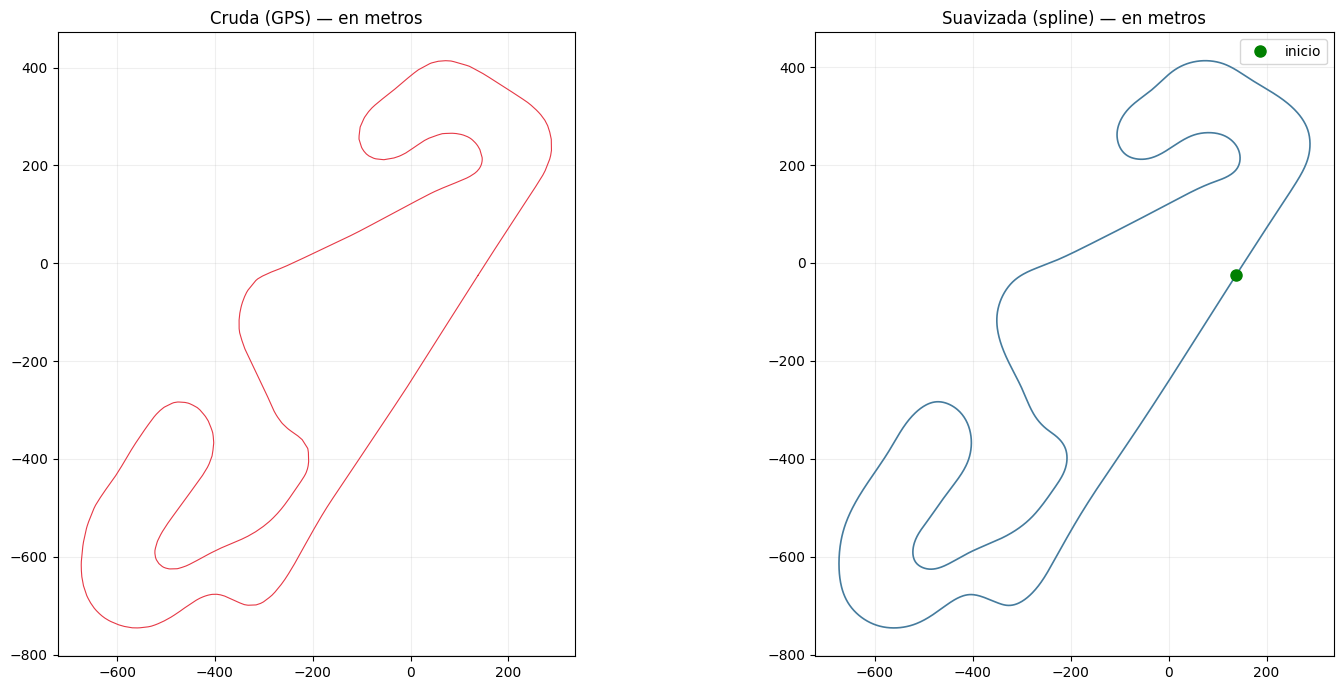

✅ Trazada suavizada: 2000 puntos


In [4]:
def suavizar_trazada(x, y, n_puntos=2000):
    """
    Spline paramétrica cerrada con suavizado más conservador.
    """
    # Eliminar duplicados consecutivos
    coords = np.column_stack([x, y])
    diffs = np.diff(coords, axis=0)
    mask = np.any(diffs != 0, axis=1)
    mask = np.append(mask, True)
    coords = coords[mask]
    x_c, y_c = coords[:, 0], coords[:, 1]

    # Aseguramos cierre explícito: el último punto = el primero
    # (necesario para que per=True funcione bien)
    if not (np.isclose(x_c[0], x_c[-1]) and np.isclose(y_c[0], y_c[-1])):
        x_c = np.append(x_c, x_c[0])
        y_c = np.append(y_c, y_c[0])

    # Longitud de la poligonal cruda como referencia
    ds = np.sqrt(np.diff(x_c)**2 + np.diff(y_c)**2)
    longitud_cruda = ds.sum()
    print(f"  Longitud poligonal cruda: {longitud_cruda:.1f} m")

    # s proporcional a la longitud — mucho más conservador
    # Regla: s ~ n_puntos * sigma^2, con sigma ~ 0.5 m de ruido GPS
    n = len(x_c)
    s = n * 0.25  # suavizado mínimo, solo elimina ruido puntual

    tck, u = splprep([x_c, y_c], s=s, per=True, k=3)

    # Remuestreo uniforme
    u_new = np.linspace(0, 1, n_puntos, endpoint=False)
    x_s, y_s = splev(u_new, tck)

    return x_s, y_s, tck

tel_pole = telemetries[0]
x_raw = tel_pole["X"].values / 10.0
y_raw = tel_pole["Y"].values / 10.0

print("Procesando trazada pole...")
x_smooth, y_smooth, tck_pole = suavizar_trazada(x_raw, y_raw)

# Verificación de cierre
dist_cierre = np.sqrt((x_smooth[0]-x_smooth[-1])**2 + (y_smooth[0]-y_smooth[-1])**2)
print(f"  Distancia inicio-fin (debe ser ~0): {dist_cierre:.3f} m")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].plot(x_raw, y_raw, linewidth=0.8, color="#e63946")
axes[0].set_title("Cruda (GPS) — en metros", fontsize=12)
axes[0].set_aspect("equal")
axes[0].grid(True, alpha=0.2)

axes[1].plot(x_smooth, y_smooth, linewidth=1.2, color="#457b9d")
axes[1].plot(x_smooth[0], y_smooth[0], 'go', markersize=8, label="inicio")
axes[1].set_title("Suavizada (spline) — en metros", fontsize=12)
axes[1].set_aspect("equal")
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()
print(f"✅ Trazada suavizada: {len(x_smooth)} puntos")

Longitud total del circuito: 4611.4 m
Curvatura máxima: 0.03765 (radio mín ≈ 26.6 m)
Curvatura media: 0.00565


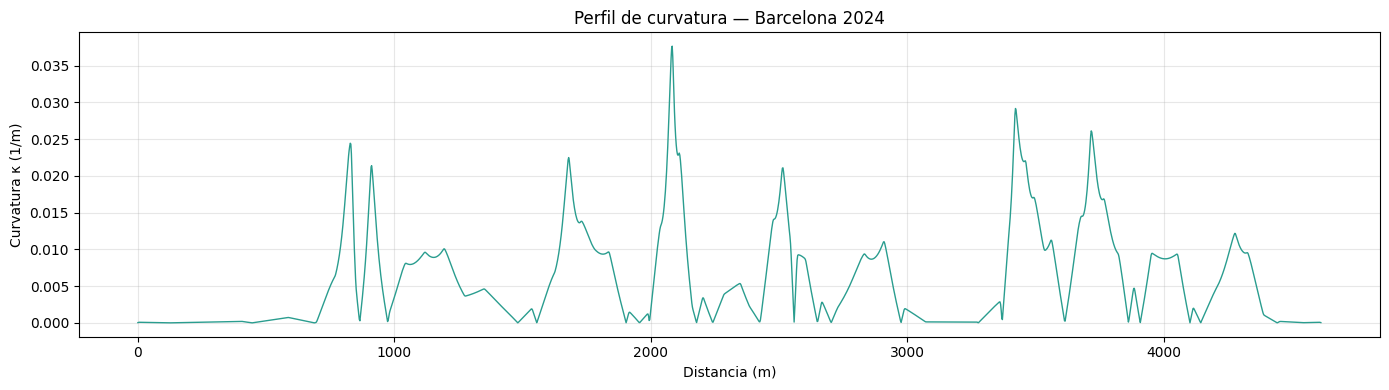

In [5]:
def calcular_curvatura(x, y):
    """
    Curvatura con diferencias centradas.
    κ = (x' y'' - y' x'') / (x'^2 + y'^2)^(3/2)
    """
    dx  = np.gradient(x)
    dy  = np.gradient(y)
    ddx = np.gradient(dx)
    ddy = np.gradient(dy)

    num = dx * ddy - dy * ddx
    den = (dx**2 + dy**2)**1.5
    # Evitamos división por cero
    den = np.where(den < 1e-6, 1e-6, den)

    kappa = num / den
    return kappa

kappa = calcular_curvatura(x_smooth, y_smooth)

# Distancia acumulada a lo largo de la trazada suavizada
ds = np.sqrt(np.diff(x_smooth)**2 + np.diff(y_smooth)**2)
dist = np.concatenate([[0], np.cumsum(ds)])

print(f"Longitud total del circuito: {dist[-1]:.1f} m")
print(f"Curvatura máxima: {np.abs(kappa).max():.5f} (radio mín ≈ {1/np.abs(kappa).max():.1f} m)")
print(f"Curvatura media: {np.abs(kappa).mean():.5f}")

# Visualización
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dist, np.abs(kappa), linewidth=1, color="#2a9d8f")
ax.set_xlabel("Distancia (m)")
ax.set_ylabel("Curvatura κ (1/m)")
ax.set_title("Perfil de curvatura — Barcelona 2024")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Guardamos la trazada de referencia suavizada
circuito = pd.DataFrame({
    "x": x_smooth,
    "y": y_smooth,
    "kappa": kappa,
    "dist": dist
})

circuito.to_csv("../data/circuito_barcelona_2024.csv", index=False)
print(f"✅ Guardado: {len(circuito)} puntos")
print(circuito.head())

✅ Guardado: 2000 puntos
            x          y     kappa      dist
0  137.666915 -25.087403  0.000042  0.000000
1  136.422578 -27.030648  0.000062  2.307504
2  135.178614 -28.974135  0.000082  4.615011
3  133.935015 -30.917860  0.000080  6.922522
4  132.691775 -32.861818  0.000079  9.230035


In [7]:
from scipy.interpolate import splprep, splev

def suavizar_trazada(x, y, n_puntos=2000):
    coords = np.column_stack([x, y])
    diffs = np.diff(coords, axis=0)
    mask = np.any(diffs != 0, axis=1)
    mask = np.append(mask, True)
    coords = coords[mask]
    x_c, y_c = coords[:, 0], coords[:, 1]
    if not (np.isclose(x_c[0], x_c[-1]) and np.isclose(y_c[0], y_c[-1])):
        x_c = np.append(x_c, x_c[0])
        y_c = np.append(y_c, y_c[0])
    n = len(x_c)
    s = n * 0.25
    tck, u = splprep([x_c, y_c], s=s, per=True, k=3)
    u_new = np.linspace(0, 1, n_puntos, endpoint=False)
    x_s, y_s = splev(u_new, tck)
    return x_s, y_s, tck

# Remuestreamos todas las trazadas a 2000 puntos para poder promediarlas
print("Remuestreando las 5 trazadas...")
trazadas_suavizadas = []
for tel in telemetries:
    x_s, y_s, _ = suavizar_trazada(
        tel["X"].values / 10.0,
        tel["Y"].values / 10.0
    )
    trazadas_suavizadas.append((x_s, y_s))
    print(f"  ✅ {tel['Driver'].iloc[0]}: {len(x_s)} puntos")

# Alineamos todas las trazadas con la pole como referencia
# (pueden empezar en puntos distintos de la vuelta)
x_pole, y_pole = trazadas_suavizadas[0]

trazadas_alineadas = [trazadas_suavizadas[0]]

for x_s, y_s in trazadas_suavizadas[1:]:
    # Encontramos el offset de fase que minimiza la distancia al punto inicial de la pole
    distancias = np.sqrt((x_s - x_pole[0])**2 + (y_s - y_pole[0])**2)
    offset = np.argmin(distancias)
    x_alin = np.roll(x_s, -offset)
    y_alin = np.roll(y_s, -offset)
    trazadas_alineadas.append((x_alin, y_alin))

# Centro geométrico: promedio de las 5 trazadas alineadas
x_centro = np.mean([t[0] for t in trazadas_alineadas], axis=0)
y_centro = np.mean([t[1] for t in trazadas_alineadas], axis=0)

print(f"\n✅ Centro geométrico calculado: {len(x_centro)} puntos")

Remuestreando las 5 trazadas...
  ✅ NOR: 2000 puntos
  ✅ VER: 2000 puntos
  ✅ HAM: 2000 puntos
  ✅ RUS: 2000 puntos
  ✅ LEC: 2000 puntos

✅ Centro geométrico calculado: 2000 puntos


Longitud centro geométrico: 4610.9 m


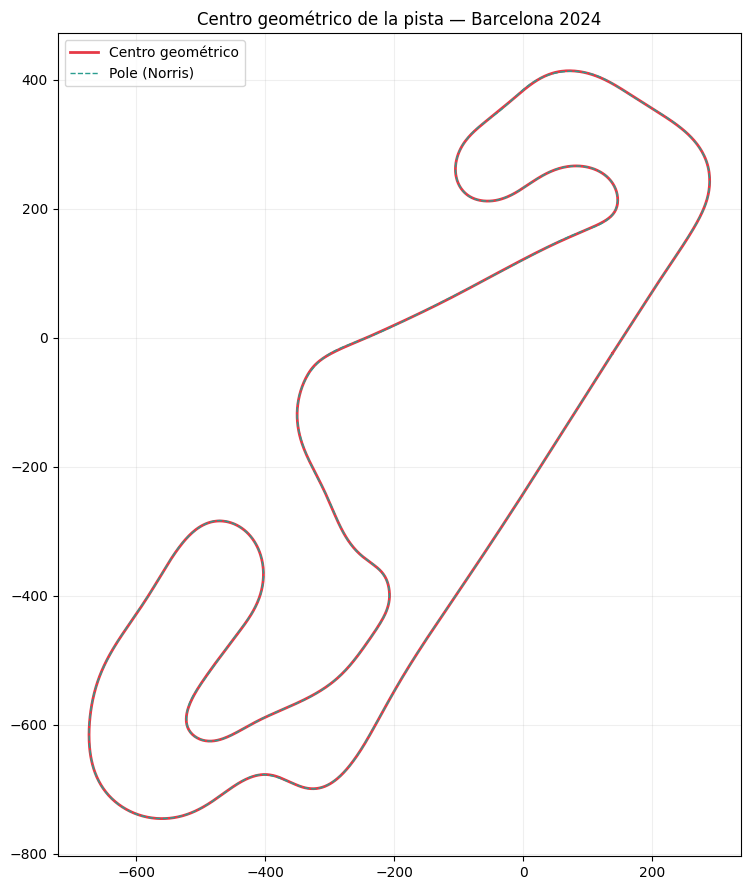

✅ CSV actualizado con centro geométrico: 2000 puntos


In [8]:
# Curvatura y distancia del centro
def calcular_curvatura(x, y):
    dx  = np.gradient(x)
    dy  = np.gradient(y)
    ddx = np.gradient(dx)
    ddy = np.gradient(dy)
    num = dx * ddy - dy * ddx
    den = (dx**2 + dy**2)**1.5
    den = np.where(den < 1e-9, 1e-9, den)
    return num / den

kappa_centro = calcular_curvatura(x_centro, y_centro)
ds_centro = np.sqrt(np.diff(x_centro)**2 + np.diff(y_centro)**2)
dist_centro = np.concatenate([[0], np.cumsum(ds_centro)])

print(f"Longitud centro geométrico: {dist_centro[-1]:.1f} m")

# Visualización comparativa
fig, ax = plt.subplots(figsize=(10, 9))

for i, (x_s, y_s) in enumerate(trazadas_alineadas):
    ax.plot(x_s, y_s, linewidth=0.6, alpha=0.4, color="#457b9d")

ax.plot(x_centro, y_centro, linewidth=2, color="#e63946", label="Centro geométrico")
ax.plot(x_pole, y_pole, linewidth=1, color="#2a9d8f",
        linestyle="--", label="Pole (Norris)")

ax.set_aspect("equal")
ax.legend()
ax.set_title("Centro geométrico de la pista — Barcelona 2024", fontsize=12)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Exportar — sobreescribimos el CSV con el centro como nueva referencia
circuito_centro = pd.DataFrame({
    "x": x_centro,
    "y": y_centro,
    "kappa": kappa_centro,
    "dist": dist_centro
})

circuito_centro.to_csv("../data/circuito_barcelona_2024.csv", index=False)
print(f"✅ CSV actualizado con centro geométrico: {len(circuito_centro)} puntos")

Longitud: 4611.4 m
Curvatura máxima: 0.03824  (radio mín: 26.1 m)
Curvatura media:  0.00565


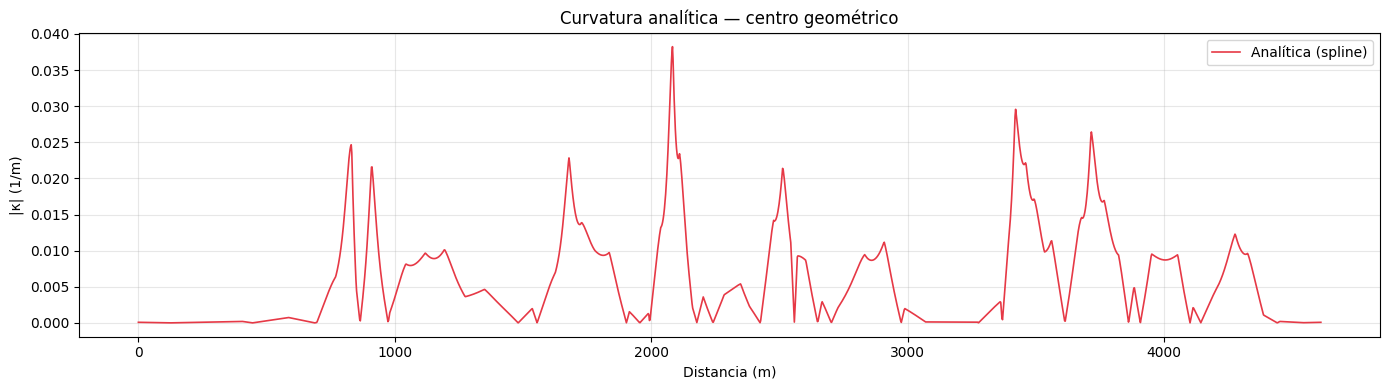

In [10]:
from scipy.interpolate import splev

def curvatura_analitica_spline(tck, u):
    """
    Curvatura exacta calculada desde las derivadas analíticas de la spline.
    κ = (x' y'' - y' x'') / (x'^2 + y'^2)^(3/2)
    """
    # Primera derivada
    dx, dy = splev(u, tck, der=1)
    # Segunda derivada
    ddx, ddy = splev(u, tck, der=2)

    num = dx * ddy - dy * ddx
    den = (dx**2 + dy**2)**1.5
    den = np.where(den < 1e-9, 1e-9, den)

    return num / den

# Parámetro uniforme para los 2000 puntos
u_uniform = np.linspace(0, 1, 2000, endpoint=False)

# Curvatura analítica desde la spline de la trazada polo (tck_pole)
kappa_analitica = curvatura_analitica_spline(tck_pole, u_uniform)

# Coordenadas desde la spline (deben coincidir con x_smooth, y_smooth)
x_analitica, y_analitica = splev(u_uniform, tck_pole)

# Distancia acumulada
ds_an = np.sqrt(np.diff(x_analitica)**2 + np.diff(y_analitica)**2)
dist_analitica = np.concatenate([[0], np.cumsum(ds_an)])

print(f"Longitud: {dist_analitica[-1]:.1f} m")
print(f"Curvatura máxima: {np.abs(kappa_analitica).max():.5f}  (radio mín: {1/np.abs(kappa_analitica).max():.1f} m)")
print(f"Curvatura media:  {np.abs(kappa_analitica).mean():.5f}")

# Comparación visual con np.gradient
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dist_analitica, np.abs(kappa_analitica),
        linewidth=1.2, color="#e63946", label="Analítica (spline)")
ax.set_xlabel("Distancia (m)")
ax.set_ylabel("|κ| (1/m)")
ax.set_title("Curvatura analítica — centro geométrico", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Longitud trayectoria óptima (spline): 4712.1 m
Curvatura máxima: 0.03145  (radio mín: 31.8 m)
Curvatura media:  0.00544


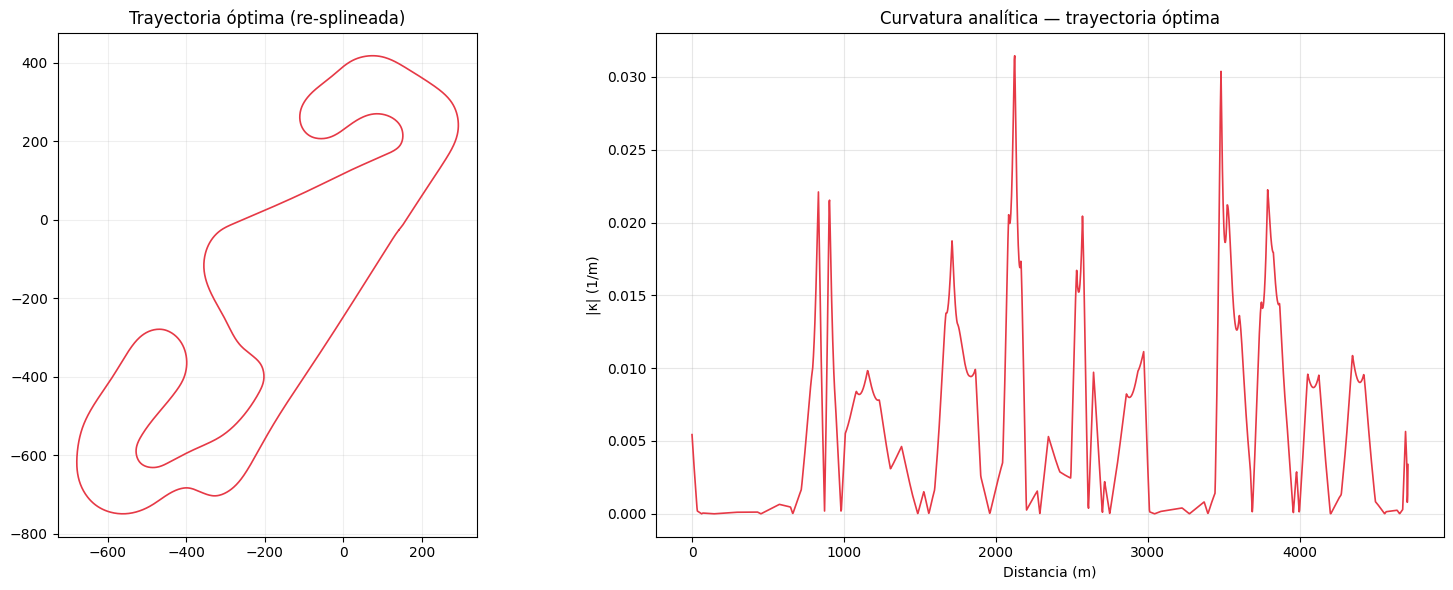

✅ CSV actualizado con curvatura analítica: 2000 puntos


In [11]:
from scipy.interpolate import splprep

# Cargamos la trayectoria óptima de la Fase 2
tray_opt = pd.read_csv("../data/trayectoria_optima_barcelona_2024.csv")
x_opt = tray_opt["x"].values
y_opt = tray_opt["y"].values

# Ajustamos una spline sobre la trayectoria óptima
# s muy pequeño: casi interpolante, solo elimina ruido residual
n = len(x_opt)
tck_opt, u_opt = splprep([x_opt, y_opt], s=n * 0.05, per=True, k=3)

# Remuestreo uniforme
u_new = np.linspace(0, 1, 2000, endpoint=False)
x_opt_s, y_opt_s = splev(u_new, tck_opt)

# Curvatura analítica de la trayectoria óptima
kappa_opt_analitica = curvatura_analitica_spline(tck_opt, u_new)

# Distancia acumulada
ds_opt = np.sqrt(np.diff(x_opt_s)**2 + np.diff(y_opt_s)**2)
dist_opt = np.concatenate([[0], np.cumsum(ds_opt)])

print(f"Longitud trayectoria óptima (spline): {dist_opt[-1]:.1f} m")
print(f"Curvatura máxima: {np.abs(kappa_opt_analitica).max():.5f}  (radio mín: {1/np.abs(kappa_opt_analitica).max():.1f} m)")
print(f"Curvatura media:  {np.abs(kappa_opt_analitica).mean():.5f}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(x_opt_s, y_opt_s, linewidth=1.2, color="#e63946")
axes[0].set_aspect("equal")
axes[0].set_title("Trayectoria óptima (re-splineada)", fontsize=12)
axes[0].grid(True, alpha=0.2)

axes[1].plot(dist_opt, np.abs(kappa_opt_analitica), linewidth=1.2, color="#e63946")
axes[1].set_xlabel("Distancia (m)")
axes[1].set_ylabel("|κ| (1/m)")
axes[1].set_title("Curvatura analítica — trayectoria óptima", fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Exportar con curvatura analítica — sobreescribimos el CSV
tray_limpia = pd.DataFrame({
    "x":     x_opt_s,
    "y":     y_opt_s,
    "kappa": kappa_opt_analitica,
    "dist":  dist_opt
})
tray_limpia.to_csv("../data/trayectoria_optima_barcelona_2024.csv", index=False)
print(f"✅ CSV actualizado con curvatura analítica: {len(tray_limpia)} puntos")